## **Data Warehousing Assignment - Movie Rental Data Warehouse Design**

##### **Name:** Tasneem Ashour, Sara Othman, and Berlanti Masalha    
##### **Date:** May 2026

---

**The notebook includes:**
- Extracting data from OLTP database
- Creating Dimension Tables
- Creating Fact Tables
- Building Bridge Tables
- Analytical Visualizations

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text

# Database Connections

Connect to:
- Source Database (OLTP)
- Destination Database (Data Warehouse)

In [2]:
username = "root"
password = "12323064"
host = "127.0.0.1"
port = 3306
srcDatabase= "filedb"
dstDatabase= "movie_rental"

srcConnection_string= f"mysql+pymysql://{username}:{password}@{host}:{port}/{srcDatabase}"
dstConnection_string= f"mysql+pymysql://{username}:{password}@{host}:{port}/{dstDatabase}"

engine1= create_engine(srcConnection_string)
engine2 = create_engine(dstConnection_string)

# Load Source Tables

Read all OLTP tables from MySQL database.

In [3]:
category= pd.read_sql("SELECT * FROM category", con=engine1)
film= pd.read_sql("SELECT * FROM film", con=engine1)
film_category = pd.read_sql("SELECT * FROM film_category", con=engine1)
language= pd.read_sql("SELECT * FROM language", con=engine1)
payment = pd.read_sql("SELECT * FROM payment", con=engine1)
rental= pd.read_sql("SELECT * FROM rental", con=engine1)
inventory= pd.read_sql("SELECT * FROM inventory",con=engine1)
customer= pd.read_sql("SELECT * FROM customer",con=engine1)
address  = pd.read_sql("SELECT * FROM address", con=engine1)
city = pd.read_sql("SELECT * FROM city",con=engine1)
country= pd.read_sql("SELECT * FROM country", con=engine1)
store= pd.read_sql("SELECT * FROM store", con=engine1)
staff = pd.read_sql("SELECT * FROM staff", con=engine1)

# Create Dimension Table: dim_film

This dimension stores film details such as:
- title
- description
- rating
- language
- film length

In [4]:
film_raw= film.merge( language[["language_id", "name"]], on="language_id", how="left")
film_raw= film_raw.rename(columns={"name": "language"})

dim_film = pd.DataFrame({
    "film_id": film_raw["film_id"],
    "title": film_raw["title"],
    "discription": film_raw["description"],
    "rating": film_raw["rating"],
    "film_length": film_raw["length"],
    "language": film_raw["language"]
})

dim_film.index.name = "film_key"
dim_film.to_sql("dim_film", con=engine2, if_exists="replace", index=True)

print(dim_film.isnull().sum())

film_id        0
title          0
discription    0
rating         0
film_length    0
language       0
dtype: int64


# Create Dimension Table: dim_category

This dimension stores film category details such as:
- category name
- category id

In [5]:
dim_category = pd.DataFrame({
    "category_id"   : category["category_id"],
    "category_name" : category["name"] })

dim_category.index.name = "category_key"
dim_category.to_sql("dim_category", con=engine2, if_exists="replace", index=True)

print(dim_category.isnull().sum())

category_id      0
category_name    0
dtype: int64


# Create Bridge Table: bridge_film_category

This bridge table resolves the many-to-many relationship between:
- films
- categories

It connects:
- film_key from dim_film
- category_key from dim_category

In [6]:
dim_film_dw = pd.read_sql("SELECT film_id, film_key FROM dim_film", con=engine2)
dim_category_dw = pd.read_sql("SELECT category_id, category_key FROM dim_category", con=engine2)

bridge = film_category.merge(dim_film_dw, on="film_id",how="left").merge(dim_category_dw, on="category_id",how="left")[["film_key", "category_key"]]

bridge.index.name = "bridge_key"
bridge.to_sql("bridge_film_category", con=engine2, if_exists="replace", index=True)

1000

# Create Dimension Table: dim_customer

This dimension stores customer details such as:
- full name
- email
- city
- country
- district
- address
- postal code

In [7]:
cust_raw = (customer.merge(address[["address_id", "address", "district", "postal_code", "city_id"]],on="address_id",how="left")
                    .merge(city[["city_id", "country_id", "city"]],on="city_id",how="left")
                    .merge(country[["country_id", "country"]],on="country_id",how="left")
            )

dim_customer = pd.DataFrame({
    "customer_id": cust_raw["customer_id"],
    "full_name": cust_raw["first_name"] + " " + cust_raw["last_name"],
    "email": cust_raw["email"],
    "ccity": cust_raw["city"],
    "ccountry": cust_raw["country"],
    "cpostel_code": cust_raw["postal_code"],
    "caddress": cust_raw["address"],
    "cdistrict": cust_raw["district"]
})

dim_customer.index.name = "customer_key"

dim_customer.to_sql("dim_customer",con=engine2,if_exists="replace",index=True)

599

# Create Dimension Table: dim_store

This dimension stores store details such as:
- manager name
- address
- city
- country
- district
- postal code

In [8]:
store_raw = (store.merge(staff[["staff_id", "first_name", "last_name"]],left_on="manager_staff_id",right_on="staff_id",how="left")
                  .merge(address[["address_id", "address", "district", "postal_code", "city_id"]],on="address_id",how="left")
                  .merge(city[["city_id", "country_id", "city"]],on="city_id",how="left")
                  .merge(country[["country_id", "country"]],on="country_id",how="left")
            )

dim_store = pd.DataFrame({
    "store_id": store_raw["store_id"],
    "manager_name": store_raw["first_name"] + " " + store_raw["last_name"],
    "saddress": store_raw["address"],
    "scity": store_raw["city"],
    "scountry": store_raw["country"],
    "sdistrict": store_raw["district"],
    "spostel_code": store_raw["postal_code"]
})

dim_store.index.name = "store_key"

dim_store.to_sql("dim_store",con=engine2,if_exists="replace",index=True)

print(dim_store.isnull().sum())

store_id        0
manager_name    0
saddress        0
scity           0
scountry        0
sdistrict       0
spostel_code    0
dtype: int64


# Create Dimension Table: dim_staff

This dimension stores staff details such as:
- full name
- email
- assigned store

In [41]:
dim_store_dw = pd.read_sql("SELECT store_id, store_key FROM dim_store", con=engine2)

dim_staff = staff.merge(dim_store_dw,on="store_id",how="left")

dim_staff = pd.DataFrame({
    "staff_id": dim_staff["staff_id"],
    "full_name":dim_staff["first_name"] + " " + dim_staff["last_name"],
    "email":dim_staff["email"],
    "staff_store_key":dim_staff["store_key"]
})

dim_staff.index.name = "staff_key"

dim_staff.to_sql("dim_staff",con=engine2,if_exists="replace",index=True)

print(dim_staff.isnull().sum())

staff_id           0
full_name          0
email              0
staff_store_key    0
dtype: int64


# Create Dimension Table: dim_date

This step combines all date columns from the operational database into a single date dimension table.

The dates are collected from:
- rental_date
- return_date
- payment_date

In [10]:
all_dates = (
    pd.concat([
        rental["rental_date"],
        rental["return_date"],
        payment["payment_date"],
    ])
)

all_dates.head()

0   2005-05-24 22:53:30
1   2005-05-24 22:54:33
2   2005-05-24 23:03:39
3   2005-05-24 23:04:41
4   2005-05-24 23:05:21
dtype: datetime64[us]

### Normalize Date Values


In [11]:
all_dates = (
    pd.concat([
        rental["rental_date"].dt.normalize(),
        rental["return_date"].dt.normalize(),
        payment["payment_date"].dt.normalize(),
    ])
)

all_dates.head()

0   2005-05-24
1   2005-05-24
2   2005-05-24
3   2005-05-24
4   2005-05-24
dtype: datetime64[us]

The `.dt.normalize()` function removes the time portion from datetime values.

Example:

Before normalize:
- 2005-05-24 22:53:30
- 2005-05-24 23:01:10

After normalize:
- 2005-05-24
- 2005-05-24

This is important because the Date Dimension should contain unique dates only, not different timestamps from the same day.

### Check for Duplicate and Missing Dates

This step checks:
- duplicate date values
- missing (NULL) dates

Duplicate dates are expected because many rentals or payments can happen on the same day.

NULL values usually come from:
- return_date for movies that were not returned yet.

In [12]:

print("duplicated")
print(all_dates.duplicated().sum())
print("null")
print(all_dates.isnull().sum())


duplicated
48041
null
183


### Clean Date Values

This step removes:
- NULL dates using `dropna()`
- duplicate dates using `drop_duplicates()`

Then the index is reset to create a clean sequential index.

In [13]:
all_dates.dropna(inplace=True)
all_dates.drop_duplicates(inplace=True)
all_dates.reset_index(drop=True, inplace=True)

In [14]:
print("duplicated")
print(all_dates.duplicated().sum())
print("null")
print(all_dates.isnull().sum())

duplicated
0
null
0


In [15]:

dim_date = pd.DataFrame({
    "full_date": all_dates,
    "month": all_dates.dt.strftime("%B"),
    "quarter": "Q" + all_dates.dt.quarter.astype(str),
    "year": all_dates.dt.year,
    "day": all_dates.dt.strftime("%A"),
})

dim_date.sort_values("full_date", inplace=True)

dim_date.index.name = "date_key"

dim_date.to_sql("dim_date",con=engine2,if_exists="replace",index=True)


90

# Create Fact Table: fact_rental_film

This fact table stores rental transaction analysis data.

Measures included:
- actual rental duration
- late return days

In [16]:
rf =(
    rental.merge(inventory[["inventory_id", "film_id", "store_id"]],on="inventory_id", how="left")
          .merge(film[["film_id", "rental_duration"]], on="film_id", how="left")
    )

### Load Dimension Keys

Load surrogate keys from:
- dim_film
- dim_store
- dim_date

In [17]:
dim_film_dw = pd.read_sql(
    "SELECT film_id, film_key FROM dim_film",
    con=engine2
)

dim_store_dw = pd.read_sql(
    "SELECT store_id, store_key FROM dim_store",
    con=engine2
)

dim_date_dw = pd.read_sql(
    "SELECT full_date, date_key FROM dim_date",
    con=engine2
)

### Calculate Actual Rental Duration

Calculate:
- return_date - rental_date

In [18]:
rf["actual_duration"] = (rf["return_date"] - rf["rental_date"]).dt.days

### Calculate Late Return Days

Calculate late days using:
- actual_duration - rental_duration

In [19]:
rf["days_late"] = (
    rf["actual_duration"] - rf["rental_duration"]
)

for i in rf.index:

    if rf.loc[i, "days_late"] < 0:

        rf.loc[i, "days_late"] = 0

### Handle Non Returned Rentals

If return_date is NULL:
- days_late = -1

In [ ]:
for i in rf.index:

    if pd.isnull(rf.loc[i, "return_date"]):

        rf.loc[i, "days_late"] = -1


np.int64(0)

### Clean data

Replace NULL values with zero.

In [21]:
rf["days_late"] = (rf["days_late"].fillna(0))

### Connect Fact Table to Dimensions

Replace business keys with surrogate keys.

In [22]:
fact_rental_film = (rf.merge(dim_film_dw,on="film_id",how="left")
                      .merge(dim_store_dw,on="store_id",how="left")
                      .merge(dim_date_dw,left_on=rf["rental_date"].dt.normalize(),right_on="full_date",how="left")
                    )

### Select Final Columns

Keep only:
- foreign keys
- measures

In [23]:
fact_rental_film = fact_rental_film[[
    "film_key",
    "store_key",
    "date_key",
    "actual_duration",
    "days_late"
]]

fact_rental_film.isnull().sum()

film_key             0
store_key            0
date_key             0
actual_duration    183
days_late            0
dtype: int64

### Handle NULL Values

NULL values in `actual_duration` were kept because the movies were not returned yet.

Since there is no `return_date`, the rental duration cannot be calculated correctly.

### Convert Keys to Integer

Convert all keys to integer type.

In [24]:
fact_rental_film = fact_rental_film.astype({
    "film_key": int,
    "store_key": int,
    "date_key": int
})

### Create Primary Key

Rename dataframe index to rental_film_key.

In [25]:
fact_rental_film.index.name = "rental_film_key"

### Store Fact Table

Save the fact table into the Data Warehouse.

In [26]:
fact_rental_film.to_sql(
    "fact_rental_film",
    con=engine2,
    if_exists="replace",
    index=True
)

16044

# Create Fact Table: fact_payment

In [27]:
pay = (payment.merge(rental[["rental_id", "inventory_id"]], on="rental_id", how="left")
              .merge(inventory[["inventory_id", "film_id", "store_id"]], on="inventory_id", how="left"))

dim_customer_dw = pd.read_sql("SELECT customer_id, customer_key FROM dim_customer", con=engine2)
dim_staff_dw = pd.read_sql("SELECT staff_id, staff_key FROM dim_staff", con=engine2)
dim_store_dw = pd.read_sql("SELECT store_id, store_key FROM dim_store", con=engine2)
dim_date_dw = pd.read_sql("SELECT full_date, date_key FROM dim_date",con=engine2)

fact_payment = (pay.merge(dim_customer_dw, on="customer_id", how="left")
                   .merge(dim_store_dw, on="store_id", how="left")
                   .merge(dim_film_dw, on="film_id", how="left")
                   .merge(dim_staff_dw, on="staff_id", how="left")
                   .merge(dim_date_dw,left_on=pay["payment_date"].dt.normalize(),right_on="full_date",how="left")   
                )

fact_payment = fact_payment[[
    "customer_key",
    "store_key",
    "film_key",
    "staff_key",
    "date_key",
    "amount"
]]


print(fact_payment.isnull().sum())


fact_payment.index.name = "payment_key"
fact_payment.to_sql("fact_payment", con=engine2, if_exists="replace", index=True)

customer_key    0
store_key       0
film_key        0
staff_key       0
date_key        0
amount          0
dtype: int64


16044

# Create Fact Table: fact_rental_customer

In [28]:
rc = rental.copy()

A copy of the rental table is created so modifications can be applied without changing the original dataset.

### Convert Dates to Monthly Level


In [29]:
dim_customer_dw = pd.read_sql(
    "SELECT customer_id, customer_key FROM dim_customer",
    con=engine2
)

dim_date_dw = pd.read_sql(
    "SELECT full_date, date_key FROM dim_date",
    con=engine2
)

dim_date_dw["month_date"] = pd.to_datetime(dim_date_dw["full_date"]).dt.to_period("M").dt.to_timestamp()
rc["rental_month"] = rc["rental_date"].dt.to_period("M").dt.to_timestamp()

The date dimension contains daily dates, but this fact table requires monthly analysis.

Example:

2005-05-24 → 2005-05-01

All dates within the same month are converted to the first day of that month.

This allows proper monthly aggregation and matching.

### Aggregate Customer Rentals
This step calculates:
- total rentals per customer
- for each month

In [30]:
agg = rc.groupby(
    ["customer_id", "rental_month"]
).size().reset_index(name="total_rental")

The size() function counts the number of rentals in each group.

Example:

| customer_id | rental_month | total_rental |
|-------------|--------------|---------------|
| 1           | 2005-05-01   | 12            |

In [31]:
fact_rental_customer = (
    agg
    .merge(dim_customer_dw, on="customer_id", how="left")
    .merge(dim_date_dw[["month_date", "date_key"]],
           left_on="rental_month",
           right_on="month_date",
           how="left")
)

fact_rental_customer = fact_rental_customer[[
    "customer_key",
    "date_key",
    "total_rental"
]]

fact_rental_customer.rename(
    columns={
        "customer_key": "rcustomer_key",
        "date_key": "rental_month_key"
    },
    inplace=True
)

fact_rental_customer.index.name = "rental_customer_key"

fact_rental_customer.to_sql(
    "fact_rental_customer",
    con=engine2,
    if_exists="replace",
    index=True
)

print(fact_rental_customer.isnull().sum())

rcustomer_key       0
rental_month_key    0
total_rental        0
dtype: int64


# Data Analysis & Visualization

The following charts help analyze:
- Rental trends
- Revenue
- Late returns
- Store performance
- Film popularity

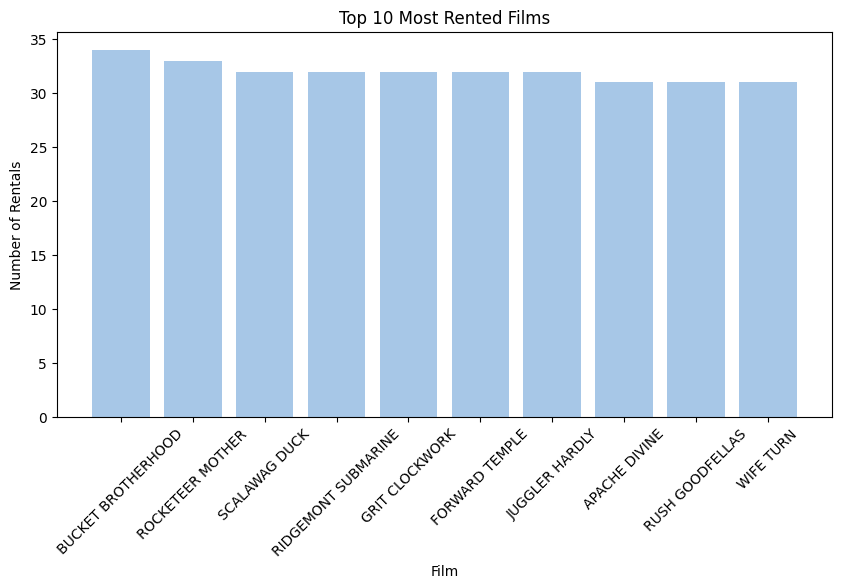

In [32]:
import matplotlib.pyplot as plt

# 1. Top 10 Most Rented Films
top_films = (
    fact_rental_film
    .merge(dim_film.reset_index(), on="film_key")
    .groupby("title")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_films.index,
    top_films.values,
    color="#A7C7E7"
)

plt.title("Top 10 Most Rented Films")
plt.xlabel("Film")
plt.ylabel("Number of Rentals")
plt.xticks(rotation=45)

plt.show()

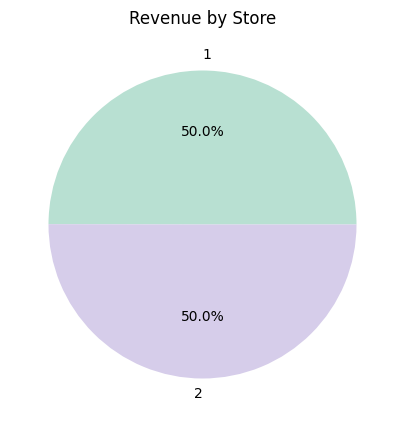

In [33]:
# 2. Revenue by Store
store_revenue = (
    fact_payment
    .merge(dim_store.reset_index(), on="store_key")
    .groupby("store_id")["amount"]
    .sum()
)

plt.figure(figsize=(7,5))

plt.pie(
    store_revenue.values,
    labels=store_revenue.index,
    autopct="%1.1f%%",
    colors=["#B8E0D2", "#D6CDEA"]
)

plt.title("Revenue by Store")

plt.show()

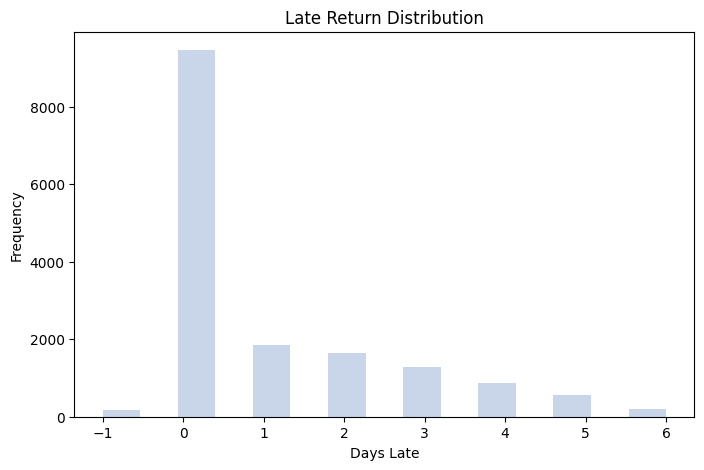

In [34]:
# 3. Late Returns Distribution
plt.figure(figsize=(8,5))

plt.hist(
    fact_rental_film["days_late"],
    bins=15,
    color="#C9D6EA"
)

plt.title("Late Return Distribution")
plt.xlabel("Days Late")
plt.ylabel("Frequency")

plt.show()

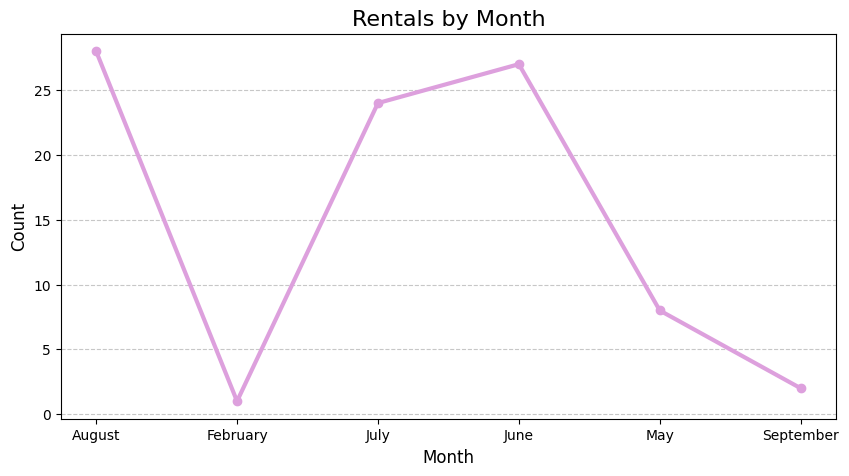

In [35]:
# 4. Rentals by Month
import matplotlib.pyplot as plt

rentals_by_month = (
    dim_date
    .groupby("month")
    .size()
)

plt.figure(figsize=(10,5))

rentals_by_month.plot(
    kind="line",
    marker="o",
    color="plum",
    linewidth=3
)

plt.title("Rentals by Month", fontsize=16)
plt.ylabel("Count", fontsize=12)
plt.xlabel("Month", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

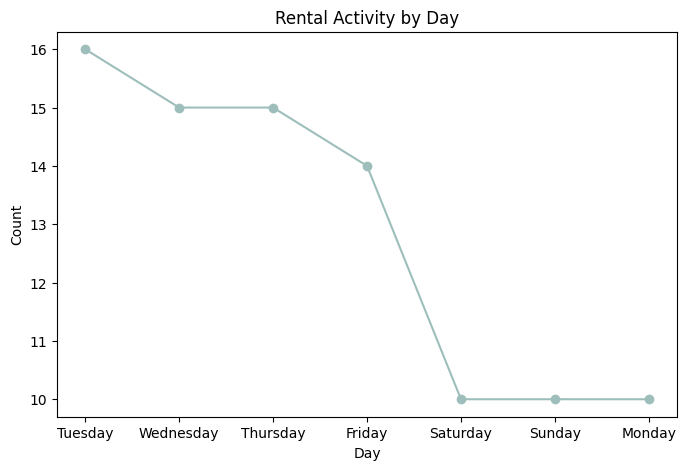

In [36]:
#rental activty by day
rentals_by_day = (
    dim_date["day"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.plot(
    rentals_by_day.index,
    rentals_by_day.values,
    marker="o",
    color="#9DBEBB"
)

plt.title("Rental Activity by Day")
plt.xlabel("Day")
plt.ylabel("Count")

plt.show()

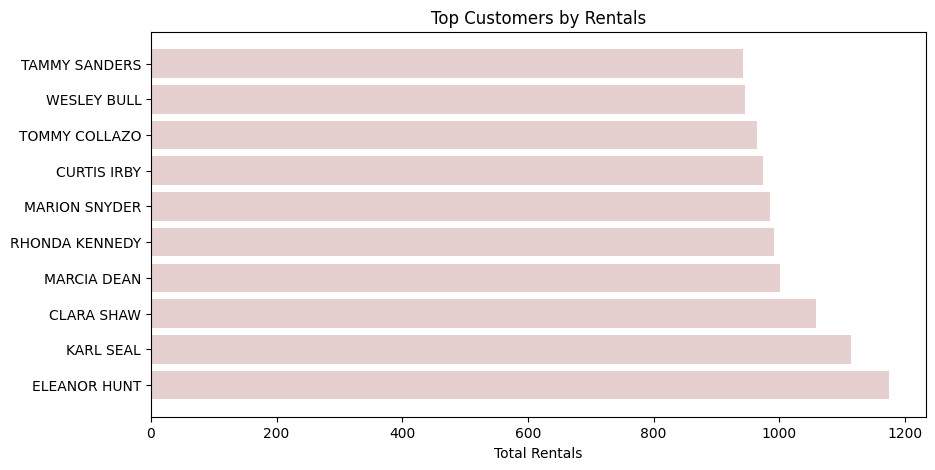

In [37]:
top_customers = (
    fact_rental_customer
    .merge(
        dim_customer.reset_index(),
        left_on="rcustomer_key",
        right_on="customer_key"
    )
    .groupby("full_name")["total_rental"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top_customers.index,
    top_customers.values,
    color="#E6CFCF"
)

plt.title("Top Customers by Rentals")
plt.xlabel("Total Rentals")

plt.show()

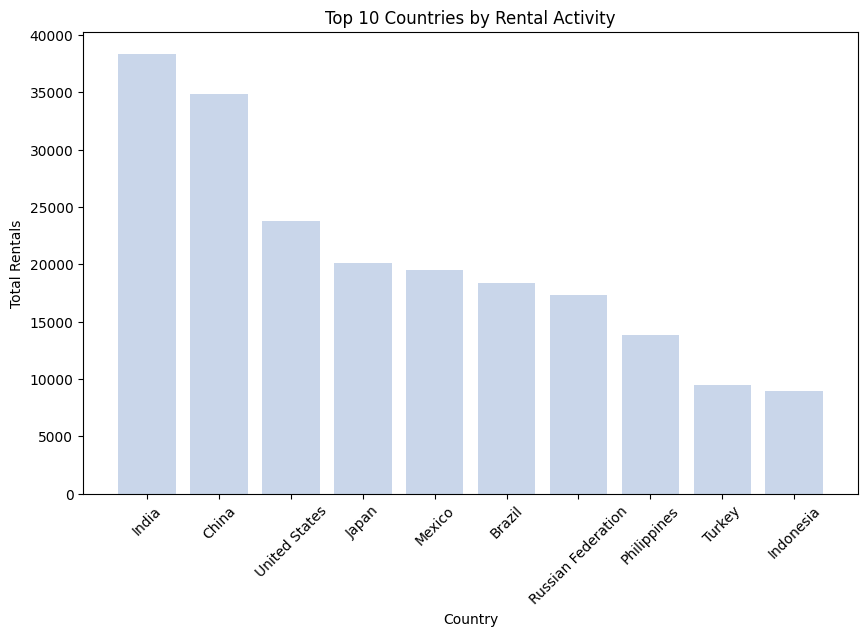

In [38]:
# Rentals by Country

top_countries = (
    fact_rental_customer.merge(dim_customer.reset_index(), left_on="rcustomer_key" ,right_on="customer_key")
    .groupby("ccountry")["total_rental"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    top_countries.index,
    top_countries.values,
    color="#C9D6EA"
)

plt.xticks(rotation=45)

plt.xlabel("Country")
plt.ylabel("Total Rentals")

plt.title("Top 10 Countries by Rental Activity")

plt.show()

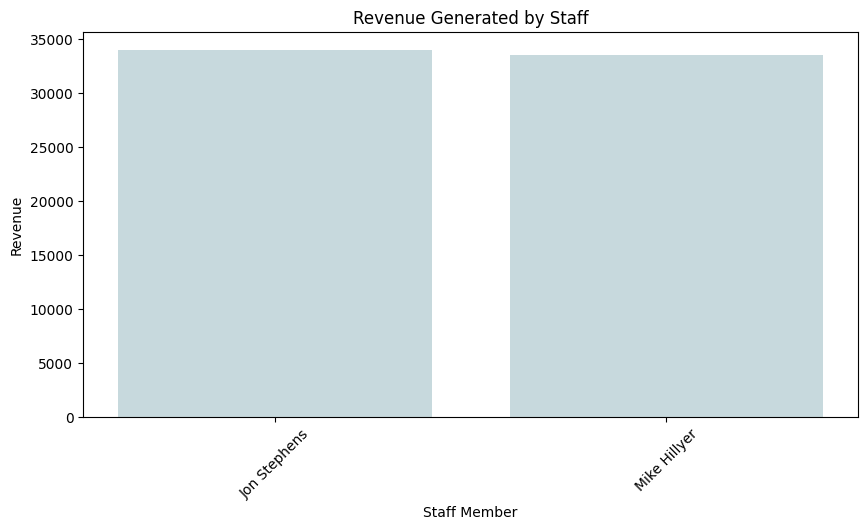

In [39]:
staff_revenue = (
    fact_payment
    .merge(dim_staff.reset_index(), on="staff_key")
    .groupby("full_name")["amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(
    staff_revenue.index,
    staff_revenue.values,
    color="#C7D9DD"
)

plt.title("Revenue Generated by Staff")
plt.xlabel("Staff Member")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# finally
This project successfully transformed a Movie Rental OLTP database into a Hybrid Data Warehouse model designed for analytical reporting and business intelligence. By applying dimensional modeling techniques and building ETL pipelines using Python, the project organized transactional data into structured fact and dimension tables that support efficient analysis and visualization.

The developed warehouse enables valuable business insights such as customer behavior analysis, rental trends, revenue tracking, store performance evaluation, and film popularity analysis. In addition, the use of data visualizations helped present analytical results in a clear and professional way.

Overall, the project demonstrates a strong understanding of:

Data Warehouse concepts
Hybrid schema design
ETL processes
Data transformation and loading
Analytical reporting using Python and MySQL